<a href="https://colab.research.google.com/github/amir-asari/SEBB4083-Assignment2025/blob/main/Miniproject_G2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Mini Project 2025 (Pain Facial Expression Detection)




### Total marks: 15 Marks

### Group No: 2

###Group Members:
1) Khoo Shi Han (A22EB5003)

2) Mayesha Mustafa Eshika (A21EB3011)

3) Nur Adriana Darwisyah Binti Haizat (A22EB0056)

4) Muhammad Aizat Naqiudin Bin Mohd Nasir (A22EB0044)

## Chapter 1: Introduction


###1.1 Background of study and related works

Pain assessment is a critical component of clinical care, particularly for non-verbal patients, such as infants, individuals with severe dementia, or patients under sedation [1]. Traditional approaches rely on patient self-report or clinician observation, which are not reliable [2]. In an effort to extract objective information from spontaneous facial gestures that represent nociceptive states, this issue has prompted academics to investigate automated pain detection from facial expressions using machine learning and deep learning.[3]

The capability of automated face analysis to enhance or substitute human grading systems was initially recognized in early studies on AI's role in pain detection. Despite being limited by small datasets and the need for manually crafted features, along with confounding factors and ethical issues regarding data collection in clinical environments, a 2023 review explored how facial action coding systems and manual feature extraction provided a foundation for machine learning.[4]

Since that time, investigations into pain detection have been primarily led by deep learning. The domain is currently led by CNN-based frameworks that autonomously detect complex, subtle patterns associated with pain expressions, eliminating the necessity for manual design. These architectures extract features directly from unprocessed images. A 2025 comprehensive review indicates that deep learning models often outperform traditional machine learning methods in pain identification tasks. Nonetheless, it also discovered significant variation in accuracy due to varying datasets, restricted sample sizes, and an absence of multicenter validation.[5]

Data diversity and availability have emerged as a major barrier, surpassing model selection. Most publicly available pain datasets are small, biased by demographics, and subject to ethical limitations, hindering models' ability to generalize to diverse real-world patients. Clinical significance is affected, for example, by the bias present in even substantial academic datasets, like UNBC-McMaster, which favor specific age groups and ethnicities.[6]


To overcome these constraints, a number of recent studies have explored with innovative network architectures and multimodal learning. Ridouan et al. demonstrated that adding sequence information can improve binary pain identification from video frames by proposing hybrid architectures that combine convolutional backbones with temporal models like LSTM to capture both spatial and temporal dynamics in facial expressions.[5]

In addition to architectural advancements, the industry has increasingly looked to synthetic data creation as a workable substitute for expensive and limited clinical datasets. Taati et al.'s introduction of SynPAIN, a sizable synthetic dataset of pain and non-pain facial expressions, is the most noteworthy recent effort. SynPAIN was validated against pain-specific action-unit measurements and properly balanced across age, gender, and ethnicity.[7]

Systematic evaluations highlight that clinical translation is still restricted despite potential advancements in design and datasets. The most accurate results are frequently published in controlled laboratory settings rather in actual clinical situations, and studies differ greatly in terms of technique, performance reporting, and target groups. Multicenter datasets and external validation are still uncommon, demonstrating the significant obstacles in the way of turning good research into a trustworthy therapeutic tool.[9]





###1.2 Objectives

1. To investigate how different training-to-testing ratios under fixed parameters impacts model accuracy and loss.

2. To compare model trained with and without augmentation in order to assess the impact of data augmentation on model generalization on synthetic pain versus no-pain face expression images.

3. To test various learning rates and monitor stability, learning speed, and final performance in order to examine the effects of important training hyperparameters, particularly learning rate, on convergence behavior and final classification accuracy when training on synthetic pictures.




## Chapter 2: Methodology and Results

**Data Acquisition & Preparation**

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import shutil
import pandas as pd

import tensorflow as tf
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.applications import MobileNetV2

from sklearn.model_selection import train_test_split

!pip install zipfile36
from zipfile36 import ZipFile

All the libraries has import and the Python environment is set up for developing deep learning image classification model using TensorFlow and Keras. The zipfile36 package has successfully installed where the compressed images can be properly extracted and managed.

In [ ]:
!gdown 1aSs7f0WmEEpVMJlM3eSGA4FhssGHiNxW

Downloading...
From (original): https://drive.google.com/uc?id=1aSs7f0WmEEpVMJlM3eSGA4FhssGHiNxW
From (redirected): https://drive.google.com/uc?id=1aSs7f0WmEEpVMJlM3eSGA4FhssGHiNxW&confirm=t&uuid=13145acb-0266-4d2f-818d-ed5dcab2f52d
To: /content/SynPain_Resized.zip
100% 73.0M/73.0M [00:00<00:00, 103MB/s] 


The dataset has been downloaded in a zip file named SynPain_Resized.zip

In [ ]:
zip_path = '/content/SynPain_Resized.zip'
extract_path = '/content/dataset/'


Location of zip file and extracted dataset has been defined

In [ ]:
import zipfile
import os

# Create extract folder if not exists
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("✅ Dataset extracted successfully")


✅ Dataset extracted successfully


Dataset extracted and prepared successfully.

In [ ]:
pain_path = None
no_pain_path = None

for root, dirs, files in os.walk(extract_path):
    for d in dirs:
        if d.lower() == 'pain':
            pain_path = os.path.join(root, d)
        if d.lower().replace(" ", "_") in ['no_pain', 'nopain']:
            no_pain_path = os.path.join(root, d)

print("Pain path found:", pain_path)
print("No Pain path found:", no_pain_path)


Pain path found: /content/dataset/SynPain_Resized/Pain
No Pain path found: /content/dataset/SynPain_Resized/NoPain


The SynPain_Resized dataset is seperated into pain and no pain facial expression in two different files.

In [ ]:
print("Pain exists:", os.path.exists(pain_path))
print("No Pain exists:", os.path.exists(no_pain_path))


Pain exists: True
No Pain exists: True


Both path are existing

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image


In [ ]:
def show_images(folder_path, title):
    images = os.listdir(folder_path)
    images = [img for img in images if img.lower().endswith(('.png', '.jpg', '.jpeg'))]

    selected_images = random.sample(images, 9)

    plt.figure(figsize=(6,6))
    for i, img_name in enumerate(selected_images):
        img_path = os.path.join(folder_path, img_name)
        img = Image.open(img_path)

        plt.subplot(3,3,i+1)
        plt.imshow(img)
        plt.axis('off')

    plt.suptitle(title, fontsize=14)
    plt.show()


Randomly select 9 images and display them into 3x3 grid

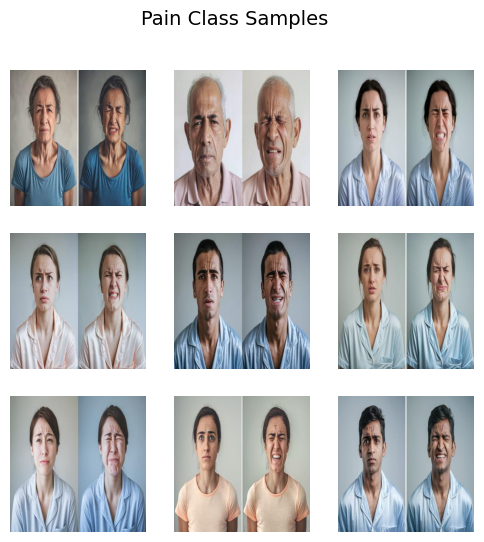

In [ ]:
show_images(pain_path, "Pain Class Samples")


3x3 grid of random images from "Pain" class are displayed correctly.

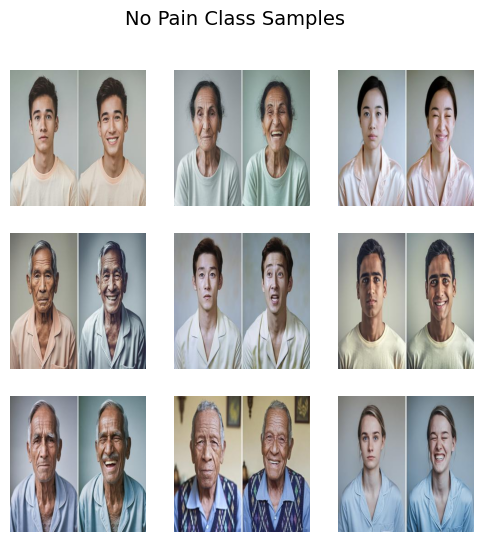

In [ ]:
show_images(no_pain_path, "No Pain Class Samples")


3x3 grid of random images of "No Pain" class are displayed correctly.

In [ ]:
print("Pain images:", len(os.listdir(pain_path)))
print("No Pain images:", len(os.listdir(no_pain_path)))


Pain images: 2737
No Pain images: 2620


There are total 2737 images from "Pain" class and 2620 images of No Pain" class.

**Experiment A**

In [ ]:
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
EPOCHS = 8
LEARNING_RATE = 1e-4

Hyperparameters of experiment A are fixed

In [ ]:
extract_path = "/content/dataset/SynPain_Resized"
output_dir = "/content/data_splits"
os.makedirs(output_dir, exist_ok=True)
classes = {"Pain": "pain", "NoPain": "no_pain"}

The dataset path is mapped with the data splits path

In [ ]:
def split_dataset(train_ratio):
    split_name = f"train_{int(train_ratio*100)}"
    split_path = os.path.join(output_dir, split_name)

    if os.path.exists(split_path):
        shutil.rmtree(split_path)

    for phase in ["train", "test"]:
        for label in classes.values():
            os.makedirs(os.path.join(split_path, phase, label), exist_ok=True)

    for folder_name, label in classes.items():
        cls_path = os.path.join(extract_path, folder_name)
        if not os.path.exists(cls_path):
            print(f" Folder {cls_path} does not exist!")
            continue
        images = [img for img in os.listdir(cls_path) if img.lower().endswith(('.jpg', '.jpeg', '.png'))]
        random.shuffle(images)
        train_size = int(len(images) * train_ratio)
        train_imgs = images[:train_size]
        test_imgs = images[train_size:]

        for img in train_imgs:
            shutil.copy(os.path.join(cls_path, img), os.path.join(split_path, "train", label, img))
        for img in test_imgs:
            shutil.copy(os.path.join(cls_path, img), os.path.join(split_path, "test", label, img))

    print(f"✅ Split {int(train_ratio*100)}:{100-int(train_ratio*100)} completed")

random.seed(42)
for ratio in [0.7, 0.8, 0.9]:
    split_dataset(ratio)

✅ Split 70:30 completed
✅ Split 80:20 completed
✅ Split 90:10 completed


The dataset are splitted into 70:30, 80:20, and 90:10 for training and testing

In [ ]:
def build_mobilenet():
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(299, 299, 3),
        include_top=False,
        weights="imagenet"
    )
    base_model.trainable = False
    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dropout(0.5),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

This function creates a binary image classification model using transfer learning with MobileNetV2. The model is compiled with the Adam optimizaer, binary cross-entropy loss, and accuracy as the evaluation metric.

In [ ]:
def get_generators(train_dir, test_dir):
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=15,
        zoom_range=0.1,
        horizontal_flip=True
    )
    test_datagen = ImageDataGenerator(rescale=1./255)
    train_gen = train_datagen.flow_from_directory(
        train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary"
    )
    test_gen = test_datagen.flow_from_directory(
        test_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode="binary", shuffle=False
    )
    return train_gen, test_gen

This function creates data generators for training and testing. The generators load images from directories in batches and resize them into defined input size.

In [ ]:
def train_and_evaluate(split_ratio):
    print(f"\nTraining with {split_ratio}:")
    train_dir = f"/content/data_splits/train_{split_ratio}/train"
    test_dir  = f"/content/data_splits/train_{split_ratio}/test"
    train_gen, test_gen = get_generators(train_dir, test_dir)
    model = build_mobilenet()
    history = model.fit(
        train_gen,
        validation_data=test_gen,
        epochs=EPOCHS,
        verbose=1
    )
    final_acc = history.history['val_accuracy'][-1]
    final_loss = history.history['val_loss'][-1]
    return history, final_acc, final_loss

This function performs training and evaluation of the MobileNetV2 model on split dataset.

In [ ]:
results = {}
for split in [70, 80, 90]:
    history, acc, loss = train_and_evaluate(split)
    results[split] = {"history": history, "accuracy": acc, "loss": loss}
    print(f"Split {split}: Accuracy={acc:.4f}, Loss={loss:.4f}")

print("\n✅ Training completed for all splits")


Training with 70:
Found 3748 images belonging to 2 classes.
Found 1607 images belonging to 2 classes.


/tmp/ipython-input-3677362339.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = tf.keras.applications.MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 127s 896ms/step - accuracy: 0.5274 - loss: 0.7380 - val_accuracy: 0.5563 - val_loss: 0.6872
Epoch 2/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 77s 651ms/step - accuracy: 0.5277 - loss: 0.7366 - val_accuracy: 0.5887 - val_loss: 0.6708
Epoch 3/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 77s 652ms/step - accuracy: 0.5480 - loss: 0.7150 - val_accuracy: 0.6291 - val_loss: 0.6539
Epoch 4/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 76s 648ms/step - accuracy: 0.5914 - loss: 0.6767 - val_accuracy: 0.6428 - val_loss: 0.6412
Epoch 5/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 76s 645ms/step - accuracy: 0.6174 - loss: 0.6624 - val_accuracy: 0.6627 - val_loss: 0.6293
Epoch 6/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 77s 651ms/step - accuracy: 0.6201 - loss: 0.6641 - val_accuracy: 0.6845 - val_loss: 0.6173
Epoch 7/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 76s 648ms/step - accuracy: 0.6200 - loss: 0.6472 - val_accuracy: 0.6945 - val_loss: 0.6079
Epoch 8/8
118/118 ━━━━━━━━━━━━━━━━━━━━ 77s 649ms/step - accuracy: 0.6493 - loss: 0.6279 -

The model is trained and evaluated with different training/testing splits (70:30, 80:20, and 90:10). For each split, the training history, final accuracy, and loss are stored and shown.

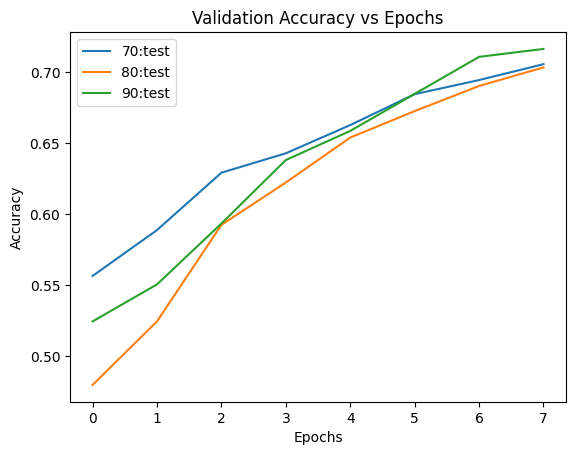

In [ ]:
plt.figure()
for split in results:
    plt.plot(results[split]["history"].history["val_accuracy"], label=f"{split}:test")

plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


The validation accuracy over epochs for three training-to-testing ratios graph is plotted

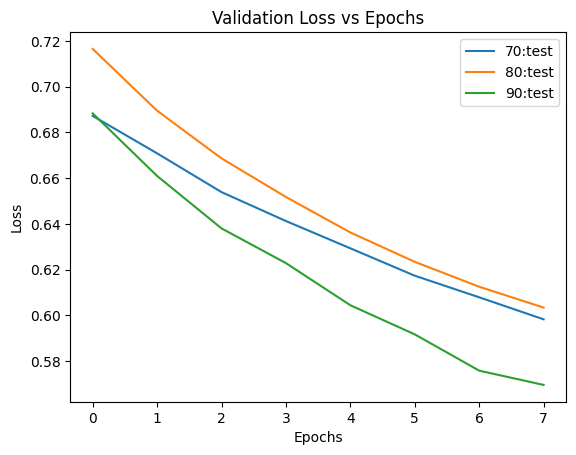

In [ ]:
plt.figure()
for split in results:
    plt.plot(results[split]["history"].history["val_loss"], label=f"{split}:test")

plt.title("Validation Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


The validation loss over epochs for three training-to-testing ratios graph is plotted

Experiment B

In [ ]:
DATA_DIR = "/content/data_splits/train_80"
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

def get_generators_exp_b(aug_enabled=False):
    if aug_enabled:
        train_datagen = ImageDataGenerator(
            rescale=1./255,
            rotation_range=20,
            zoom_range=0.2,
            horizontal_flip=True
        )
    else:
        train_datagen = ImageDataGenerator(
            rescale=1./255
        )

    test_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_directory(
        os.path.join(DATA_DIR, "train"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=True
    )

    test_gen = test_datagen.flow_from_directory(
        os.path.join(DATA_DIR, "test"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    return train_gen, test_gen

The function created training and testing data generators with an option to enable or disable data augmentation.

In [ ]:
def build_mobilenet_exp_b():
    base_model = MobileNetV2(
        input_shape=(299,299,3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation="relu")(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

MobileNetV2 model is built.

In [ ]:
EPOCHS = 8

print("\n--- Experiment B: NO AUGMENTATION ---")
train_no_aug, test_gen = get_generators_exp_b(aug_enabled=False)
model_no_aug = build_mobilenet_exp_b()
history_no_aug = model_no_aug.fit(
    train_no_aug,
    validation_data=test_gen,
    epochs=EPOCHS
)

print("\n--- Experiment B: WITH AUGMENTATION ---")
train_aug, _ = get_generators_exp_b(aug_enabled=True)
model_aug = build_mobilenet_exp_b()
history_aug = model_aug.fit(
    train_aug,
    validation_data=test_gen,
    epochs=EPOCHS
)


--- Experiment B: NO AUGMENTATION ---
Found 4283 images belonging to 2 classes.
Found 1072 images belonging to 2 classes.


/tmp/ipython-input-1121570940.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 39s 218ms/step - accuracy: 0.6691 - loss: 0.5999 - val_accuracy: 0.8657 - val_loss: 0.3299
Epoch 2/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 14s 105ms/step - accuracy: 0.8660 - loss: 0.3208 - val_accuracy: 0.8759 - val_loss: 0.2929
Epoch 3/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - accuracy: 0.8889 - loss: 0.2716 - val_accuracy: 0.9067 - val_loss: 0.2311
Epoch 4/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 12s 89ms/step - accuracy: 0.9131 - loss: 0.2191 - val_accuracy: 0.8731 - val_loss: 0.2937
Epoch 5/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9163 - loss: 0.2003 - val_accuracy: 0.9160 - val_loss: 0.2179
Epoch 6/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 14s 102ms/step - accuracy: 0.9348 - loss: 0.1725 - val_accuracy: 0.9049 - val_loss: 0.2319
Epoch 7/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - accuracy: 0.9317 - loss: 0.1769 - val_accuracy: 0.9095 - val_loss: 0.2225
Epoch 8/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 12s 91ms/step - accuracy: 0.9398 - loss: 0.1579 - va

The model is trained and evaluated using 80:20 split dataset that no augmentation and with augmentation (rotation, flipping, and zoom). The accuracy and loss of each epoch are shown.

In [ ]:
print("\n===== FINAL COMPARISON =====")

print("NO AUGMENTATION")
print(f"Val Accuracy: {history_no_aug.history['val_accuracy'][-1]:.4f}")
print(f"Val Loss    : {history_no_aug.history['val_loss'][-1]:.4f}")

print("\nWITH AUGMENTATION")
print(f"Val Accuracy: {history_aug.history['val_accuracy'][-1]:.4f}")
print(f"Val Loss    : {history_aug.history['val_loss'][-1]:.4f}")


===== FINAL COMPARISON =====
NO AUGMENTATION
Val Accuracy: 0.9049
Val Loss    : 0.2329

WITH AUGMENTATION
Val Accuracy: 0.8461
Val Loss    : 0.3483


The validation accuracy and validation loss values for both no augmentation and with augmentation are shown.

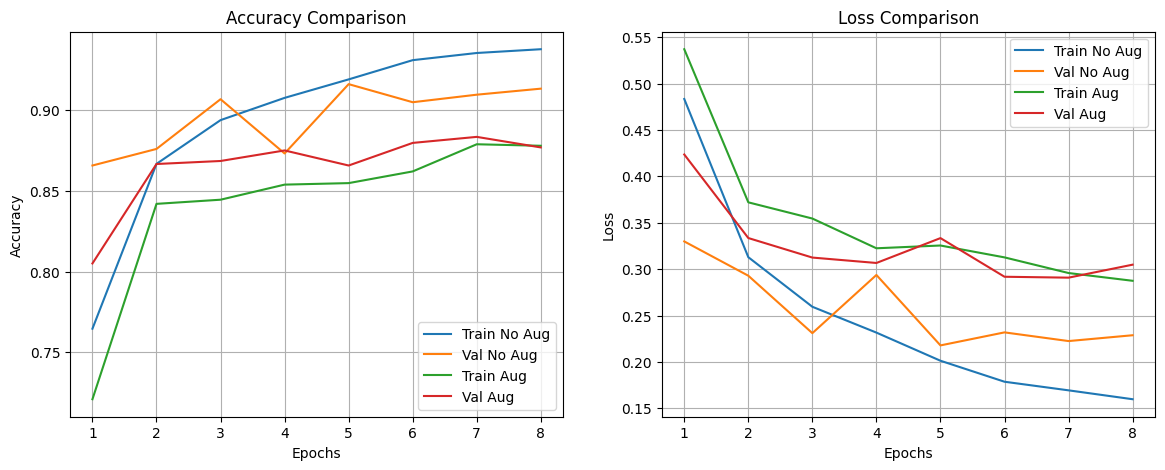

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history_no_aug.history['accuracy']) + 1)

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
plt.plot(epochs, history_no_aug.history['accuracy'], label='Train No Aug')
plt.plot(epochs, history_no_aug.history['val_accuracy'], label='Val No Aug')
plt.plot(epochs, history_aug.history['accuracy'], label='Train Aug')
plt.plot(epochs, history_aug.history['val_accuracy'], label='Val Aug')
plt.title("Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(epochs, history_no_aug.history['loss'], label='Train No Aug')
plt.plot(epochs, history_no_aug.history['val_loss'], label='Val No Aug')
plt.plot(epochs, history_aug.history['loss'], label='Train Aug')
plt.plot(epochs, history_aug.history['val_loss'], label='Val Aug')
plt.title("Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

The accuracy over epochs and loss over epochs graphs for both conditions are plotted.

34/34 ━━━━━━━━━━━━━━━━━━━━ 14s 232ms/step


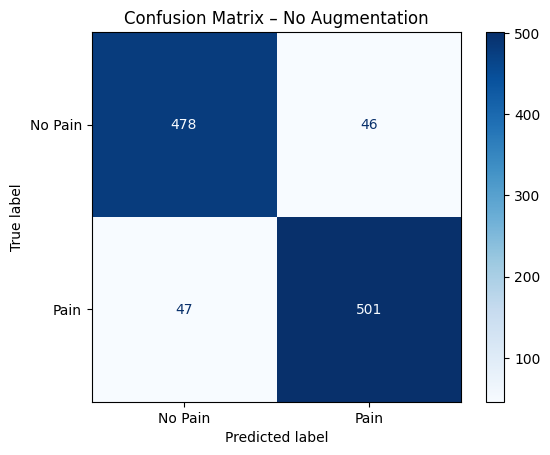

34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 260ms/step


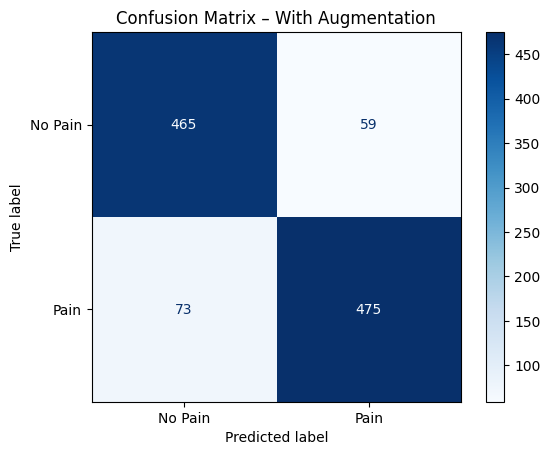

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model, generator, title):
    y_true = generator.classes
    y_pred = model.predict(generator)
    y_pred = (y_pred > 0.5).astype(int)

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Pain", "Pain"]
    )

    disp.plot(cmap="Blues")
    plt.title(title)
    plt.show()

plot_confusion_matrix(model_no_aug, test_gen, "Confusion Matrix – No Augmentation")
plot_confusion_matrix(model_aug, test_gen, "Confusion Matrix – With Augmentation")

The confusion matrix for dataset with augmentation and no augmentation are shown. The values of TP, TN, FP, and FN can be known in the confusion matrix above.

EXPERIMENT C

In [ ]:
DATA_DIR = "/content/data_splits/train_80"
IMG_SIZE = (299, 299)
BATCH_SIZE = 32

def get_generators_exp_c():
    train_datagen = ImageDataGenerator(
        rescale=1./255,
        rotation_range=20,
        zoom_range=0.2,
        horizontal_flip=True
    )

    test_datagen = ImageDataGenerator(rescale=1./255)

    train_gen = train_datagen.flow_from_directory(
        os.path.join(DATA_DIR, "train"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=True
    )

    test_gen = test_datagen.flow_from_directory(
        os.path.join(DATA_DIR, "test"),
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="binary",
        shuffle=False
    )

    return train_gen, test_gen


The dataset fixed to apply data augmentation by using 80:20 split dataset.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

def build_mobilenet_exp_c(lr):
    base_model = MobileNetV2(
        input_shape=(299,299,3),
        include_top=False,
        weights="imagenet"
    )

    base_model.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation="relu")(x)
    output = Dense(1, activation="sigmoid")(x)

    model = Model(base_model.input, output)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


MobileNetV2 model is built.

In [ ]:
EPOCHS = 8

learning_rates = {
    "High Learning Rate (0.01)": 0.01,
    "Standard Learning Rate (0.001)": 0.001,
    "Low Learning Rate (0.0001)": 0.0001
}

train_gen, test_gen = get_generators_exp_c()

histories = {}

for label, lr in learning_rates.items():
    print(f"\n--- Training with {label} ---")
    model = build_mobilenet_exp_c(lr)
    history = model.fit(
        train_gen,
        validation_data=test_gen,
        epochs=EPOCHS
    )
    histories[label] = history

Found 4283 images belonging to 2 classes.
Found 1072 images belonging to 2 classes.

--- Training with High Learning Rate (0.01) ---


/tmp/ipython-input-3110764480.py:7: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


Epoch 1/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 121s 831ms/step - accuracy: 0.6388 - loss: 0.9681 - val_accuracy: 0.8461 - val_loss: 0.3707
Epoch 2/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 98s 734ms/step - accuracy: 0.8148 - loss: 0.3973 - val_accuracy: 0.8041 - val_loss: 0.4263
Epoch 3/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 122s 909ms/step - accuracy: 0.8453 - loss: 0.3496 - val_accuracy: 0.8050 - val_loss: 0.4429
Epoch 4/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 106s 792ms/step - accuracy: 0.8503 - loss: 0.3289 - val_accuracy: 0.8647 - val_loss: 0.3282
Epoch 5/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 122s 642ms/step - accuracy: 0.8534 - loss: 0.3243 - val_accuracy: 0.8442 - val_loss: 0.3725
Epoch 6/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 106s 795ms/step - accuracy: 0.8810 - loss: 0.2897 - val_accuracy: 0.8937 - val_loss: 0.2796
Epoch 7/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 95s 706ms/step - accuracy: 0.8712 - loss: 0.2947 - val_accuracy: 0.8815 - val_loss: 0.3162
Epoch 8/8
134/134 ━━━━━━━━━━━━━━━━━━━━ 86s 642ms/step - accuracy: 0.8587 - loss: 0.30

The model is trained and evaluated using 80:20 split dataset with different learning rates (0.01, 0.001, 0.0001). The values of accuracy and loss are shown.

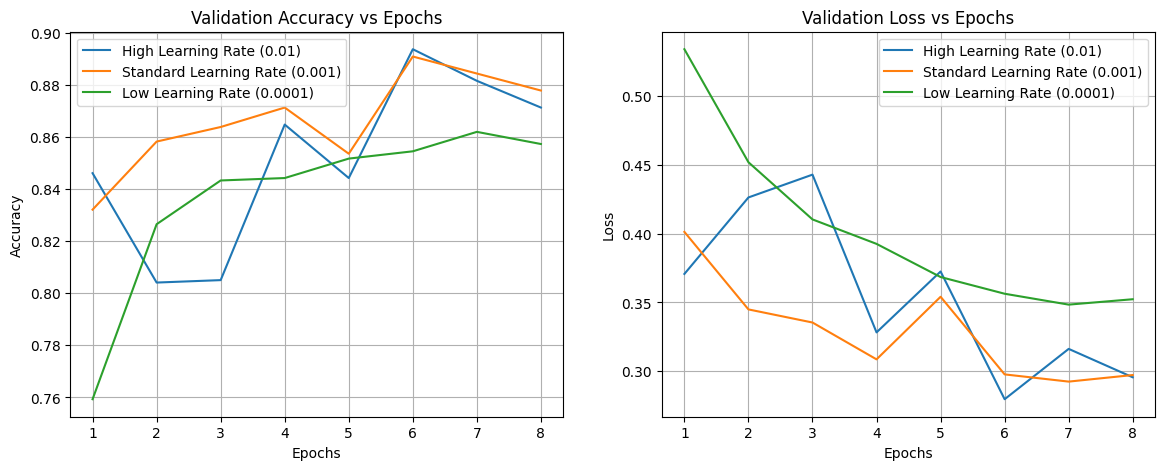

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(14,5))

# Accuracy
plt.subplot(1,2,1)
for label, hist in histories.items():
    plt.plot(epochs, hist.history['val_accuracy'], label=label)
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

# Loss
plt.subplot(1,2,2)
for label, hist in histories.items():
    plt.plot(epochs, hist.history['val_loss'], label=label)
plt.title("Validation Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

The accuracy over epochs and loss over epochs graphs for the three different learning rates are plotted.

In [ ]:
print("\n===== FINAL RESULTS: Experiment C =====")
for label, hist in histories.items():
    print(f"{label}")
    print(f"  Final Validation Accuracy: {hist.history['val_accuracy'][-1]:.4f}")
    print(f"  Final Validation Loss    : {hist.history['val_loss'][-1]:.4f}")


===== FINAL RESULTS: Experiment C =====
High Learning Rate (0.01)
  Final Validation Accuracy: 0.8713
  Final Validation Loss    : 0.2955
Standard Learning Rate (0.001)
  Final Validation Accuracy: 0.8778
  Final Validation Loss    : 0.2972
Low Learning Rate (0.0001)
  Final Validation Accuracy: 0.8573
  Final Validation Loss    : 0.3523


The results of final validation accuracy and final validation loss for all three learning rates are shown.

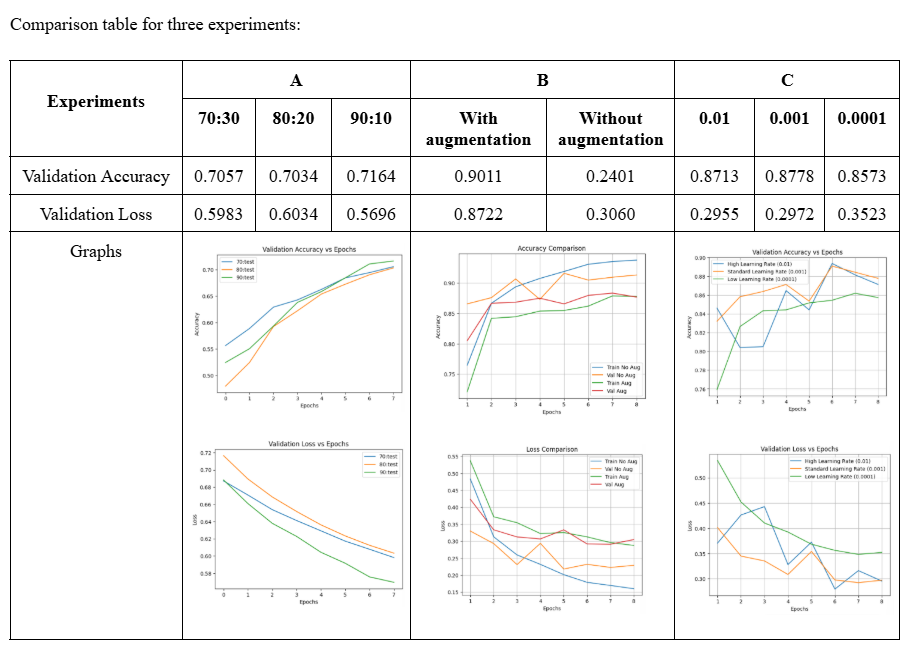

## Chapter 3: Discussion


**Experiment A**

*1. Analysis of Validation Accuracy*

- All three ratios (70:30, 80:20, 90:10) show a clear upward trend from Epoch 0 to Epoch 7. This indicates that the MobileNetV2 model is successfully learning to distinguish between "pain" and "No Pain" regardless of the split.
- According to the graph, the 90:10 ratio showed significant improvement. By Epoch 5, it surpass other ratios and achived highest final accuracy approximately at 0.71.

*2. Analysis of Validation Loss*
- The validation loss indicates how successfully the model generalises to
new, previously unknown data. All three lines are moving downward indicating an important sign of a good and stable training process [10]
- By observing at the steep downward curves, all ratios have not yet converged to a flat bottom. This concludes that the model is technically underfit in its current state because it stopped too early.
- The 90:10 test ends at the lowest point, approximately at 0.57 when compared with others. A lower loss means the model is more confident in its prediction

Summary: In terms of performance, the 90:10 Split (Green Line) is the best performing ratio for this experiment due to its high learning capacity (90% of dataset) and lowest loss indicating the model's precise prediction.




**Experiment B**

*1. Higher Performance Without Augmentation*
- The "Val No Aug" (Orange line) consistently stays above the "Val Aug" (Red line) in accuracy. Similarly, the loss for the non-augmented model is significantly lower.
- Besides that, the augmented model curves (Red and Green) are  "zig-zag" compared to the smoother non-augmented lines. This suggests that the augmentation (Rotation, Zoom, Flip) made the learning task much more difficult for the model.

*2. Quantitative Comparison*
- No Augmentation: Successfully classified 979 images (478 True Negatives + 501 True Positives).
- With Augmentation: Successfully classified 940 images (465 True Negatives + 475 True Positives).

Summary: The application of augmentation resulted in a significant increase in the number of False Positives and False Negatives. The False Positives increased from 46 to 59 and the False Negatives (those who had not expressed pain) increased from 47 to 73. In a clinical setting, having a high number of False Negatives is particularly problematic because it will mean that the system has failed to identify patients who are in pain.

The results presented on the Comparison Table support that augmemented data leads to a high level of accuracy, however, if taking a closer look at the Confusion Matrices and Training Graphs you will see that without augmentation, it actually achieved superior performance (91.3% vs 87.7%). In addition, the model without augmentation has higher stability and accuracy. This can be seen in the smooth upward trajectory of the Accuracy Comparison graph, in contrast to the augmented model, which had a significantly higher Validation Loss.




**Experiment C**

- High Learning Rate (0.01): This setting was the most unstable. The blue line shows sharp "spikes" and drops, indicating that the model was overshooting the optimal weights. Large steps in the weight space caused the model to oscillate around the solution rather than settling into it.
- Low Learning Rate (0.0001): This was the most stable setting, producing the smoothest curves. However, its convergence speed was too slow. Within the 8-epoch limit, it failed to reach the deeper parts of the loss landscape, finishing with the lowest accuracy (0.8573).
- Standard Learning Rate (0.001): This was the best setting. It provided a balanced gradient descent path that was stable enough to avoid wild oscillations but just enough to achieve the highest final accuracy (0.8778).


## Chapter 4: Conclusion

The purpose of this project was to develop an Automated Pain Detection System using the SynPAIN synthetic dataset and Transfer Learning. In this project, MobileNetV2 architecture succesfully classified facial expressions into 'Pain' and 'No Pain' and systematically analyze the impact of data splitting, augmentation and hyperparameters on model performance.

From the experiment A, it is found that the 90:10 split provided the highest accuracy which is 0.7164. This indicates that maximizing the training data volume is crucial for synthetic datasets. However, the following experiments used the 80:20 split to ensure a statistically significant validation set.

The experiment B found that the model trained without augmentation to have significantly outperformed the augmented model with accuracy 0.9132 and 0.8769 respectively. This suggest that the synthetic images posses clean and distinct features that aggresive geometric distortion like rotation and zoom may obscure within limited training window.

In the experiment C, the Standard Learning Rate (0.001) was proven to be superior than Low and High Learning Rate by achieving the accuracy of 0.8778. The Low Learning Rate shows that it resulted to slow convergence while The High Learning Rate resulted in volatility.

The final optimized model achieved a peak validation accuracy of 0.9132 in Experiment B for model without augmentation. Based on these results, the system is considered highly reliable for the task of classifying synthetic facial expressions.


## References
[1]  Payen J-F, Bru O, Bosson J-L, Lagrasta A, Novel E, Deschaux I, et al. Assessing pain in critically ill sedated patients by using a behavioral pain scale. Crit Care Med. (2001) 29(12):2258–63. 10.1097/00003246-200112000-00004

[2] Puntillo K. Pain assessment and management in the critically ill: wizardry or science? Am J Crit Care. (2003) 12(4):310–6. 10.4037/ajcc2003.12.4.310

[3] G. D. De Sario et al., “Using AI to Detect Pain through Facial Expressions: A Review,” Bioengineering, vol. 10, no. 5, p. 548, May 2023, doi: 10.3390/bioengineering10050548. https://pmc.ncbi.nlm.nih.gov/articles/PMC10215219/

[4] Á. Sabater-Gárriz et al., “Automated facial recognition system using deep learning for pain assessment in adults with cerebral palsy,” Digit. Health, vol. 10, 2024, Art. no. 20552076241259664, doi: 10.1177/20552076241259664.

[5] A. Ridouan, A. Bohi, and Y. Mourchid, “Improving Pain Classification using Spatio-Temporal Deep Learning Approaches with Facial Expressions,” arXiv preprint arXiv:2501.06787, 2025. https://arxiv.org/pdf/2501.06787

[6] M. Cascella, D. Esposito, M. R. Muzio, V. Cascella, and V. Cerrone, “Artificial intelligence for pain assessment via facial expression recognition (2015–2025): a systematic review,” Explor. Med., vol. 6, Art. no. 1001370, 2025, doi: 10.37349/emed.2025.1001370.

[7] B. Taati et al., “SynPAIN: A Synthetic Dataset of Pain and Non-Pain Facial Expressions,” arXiv preprint arXiv:2507.19673, 2025. https://arxiv.org/html/2507.19673v1

[8] X. L. Lin, S. Mehraban, A. Moturu, and B. Taati, “Pain in 3D: Generating Controllable Synthetic Faces for Automated Pain Assessment,” arXiv preprint arXiv:2509.16727, 2025.

[9] J. Huo, Y. Yu, W. Lin, A. Hu, and C. Wu, “Application of AI in Multilevel Pain Assessment Using Facial Images: Systematic Review and Meta-Analysis,” J. Med. Internet Res., vol. 26, e51250, 2024, doi: 10.2196/51250. https://www.jmir.org/2024/1/e51250

[10] S. I. Egwunatum, O. A. Osadola, and J. Oboshior, “Exploring a recurrent neural network (RNN) earned value based model for predicting lost labour value in construction projects,” Discover Civil Engineering, vol. 1, no. 1, Dec. 2024, doi: https://doi.org/10.1007/s44290-024-00153-0.
‌